In [ ]:
# Run in a Colab cell
!pip install -q sentence-transformers faiss-cpu pandas scikit-learn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 127.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 96.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 81.2 MB/s eta 0:00:00


In [ ]:
!pip install -q transformers

In [ ]:
import numpy as np, pandas as pd
import os, sys, time, math
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import torch
from sentence_transformers import SentenceTransformer
from transformers import pipeline
from sentence_transformers import CrossEncoder
import faiss
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity


print("Torch version:", torch.__version__, " CUDA available:", torch.cuda.is_available())
print("All imports done.")

Torch version: 2.6.0+cu124  CUDA available: True
All imports done.


In [ ]:
# Paths (change if needed)
BOOKS_CSV = "cleaned_dataset.csv"    # your file with columns: user_id, book_id, rating, title, genre, description
GAMES_CSV = "steam_combined_data.csv"    # your file with columns: appid, name, categories, genres, steamspy_tags, short_description

# Load
books = pd.read_csv(BOOKS_CSV)
games = pd.read_csv(GAMES_CSV)

print("Books:", books.shape, "Games:", games.shape)
# Quick peek
books.head(2), games.head(2)

Books: (853984, 6) Games: (27075, 6)


(   user_id  book_id  rating  \
 0        1     4893       3   
 1        1     1180       4   
 
                                                title         genre  \
 0  Brunelleschi's Dome: How a Renaissance Genius ...  Architecture   
 1                            The Forty Rules of Love       Fiction   
 
                                          description  
 0  Tells the story of how fifteenth-century golds...  
 1  In this lyrical, exuberant tale, acclaimed Tur...  ,
    appid                   name  \
 0     10         Counter-Strike   
 1     20  Team Fortress Classic   
 
                                           categories  genres  \
 0  Multi-player;Online Multi-Player;Local Multi-P...  Action   
 1  Multi-player;Online Multi-Player;Local Multi-P...  Action   
 
             steamspy_tags                                  short_description  
 0  Action;FPS;Multiplayer  Play the world's number 1 online action game. ...  
 1  Action;FPS;Multiplayer  One of the most popular

In [ ]:
# Ensure strings, fill NAs
for c in ['description','title','genre']:
    if c in books.columns:
        books[c] = books[c].fillna("").astype(str)
for c in ['short_description','name','genres','steamspy_tags','categories']:
    if c in games.columns:
        games[c] = games[c].fillna("").astype(str)

In [ ]:
# basic fillna for text columns (so encoder doesn't blow)
for c in ['description','title','genre']:
    if c in books.columns:
        books[c] = books[c].fillna("").astype(str)
for c in ['short_description','name','genres','steamspy_tags','categories']:
    if c in games.columns:
        games[c] = games[c].fillna("").astype(str)

print("Books rows:", len(books), "Games rows:", len(games))
# save cleaned versions
books.to_csv("books_cleaned.csv", index=False)
games.to_csv("games_cleaned.csv", index=False)
print("CELL 1 DONE — cleaned CSVs saved: books_cleaned.csv, games_cleaned.csv")

Books rows: 853984 Games rows: 27075
CELL 1 DONE — cleaned CSVs saved: books_cleaned.csv, games_cleaned.csv


In [ ]:
# CELL 2: load Sentence-BERT, Cross-Encoder, and Zero-shot pipeline
EMBED_MODEL = "all-MiniLM-L6-v2"
CROSS_ENCODER_MODEL = "cross-encoder/ms-marco-MiniLM-L-6-v2"
ZS_MODEL = "facebook/bart-large-mnli"

print("Loading embedding model:", EMBED_MODEL)
embed_model = SentenceTransformer(EMBED_MODEL)

print("Loading cross-encoder (rerank):", CROSS_ENCODER_MODEL)
cross_encoder = CrossEncoder(CROSS_ENCODER_MODEL, device=0 if torch.cuda.is_available() else -1)

print("Loading zero-shot pipeline for personality extraction:", ZS_MODEL)
device_id = 0 if torch.cuda.is_available() else -1
zero_shot = pipeline("zero-shot-classification", model=ZS_MODEL, device=device_id)

print("CELL 2 DONE — models loaded (embedding, cross-encoder, zero-shot).")

Loading embedding model: all-MiniLM-L6-v2


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


CELL 2 DONE — models loaded (embedding, cross-encoder, zero-shot).


In [ ]:
# CELL 3: helper functions

# trait list for Big Five
traits = ["Openness", "Conscientiousness", "Extraversion", "Agreeableness", "Neuroticism"]

def make_book_text_for_personality(row):
    parts = [row.get('title',''), row.get('genre',''), row.get('description','')]
    return " . ".join([str(p) for p in parts if p])

def make_book_tag_text(row):
    return str(row.get('genre',''))

def make_game_text_for_personality(row):
    parts = [row.get('name',''), row.get('genres',''), row.get('steamspy_tags',''), row.get('short_description','')]
    return " . ".join([str(p) for p in parts if p])

def make_game_tag_text(row):
    parts = []
    for k in ['genres','steamspy_tags','categories']:
        if k in row and str(row[k]).strip():
            parts.append(str(row[k]))
    return " ; ".join(parts)

def rating_weight(r):
    # maps 1..5 -> -1..+1 (negative means dislike subtracts)
    return (float(r) - 3.0) / 2.0

def bayesian_shrink(raw_vec, prior_vec, n, alpha=10.0):
    return (n * raw_vec + alpha * prior_vec) / (n + alpha)

In [ ]:
# CELL 4: compute book-level embedding + personality vector (unique books)
BOOK_BETA = 0.35   # tag vs desc fusion weight (tune)
batch_size = 64

books_unique = books.drop_duplicates(subset=['book_id']).reset_index(drop=True)
print("Unique books:", len(books_unique))

# Build tag_text and desc_text lists
book_ids = books_unique['book_id'].tolist()
tag_texts = [make_book_tag_text(r) for _, r in books_unique.iterrows()]
desc_texts = [r.get('description','') for _, r in books_unique.iterrows()]
persona_texts = [make_book_text_for_personality(r) for _, r in books_unique.iterrows()]

# 1) embeddings: do in batches for speed
all_tag_emb = embed_model.encode(tag_texts, batch_size=batch_size, show_progress_bar=True, convert_to_numpy=True)
all_desc_emb = embed_model.encode(desc_texts, batch_size=batch_size, show_progress_bar=True, convert_to_numpy=True)
book_embs = (BOOK_BETA * all_tag_emb + (1-BOOK_BETA) * all_desc_emb).astype(np.float32)

# 2) personality via zero-shot (iterative)
book_personas = []
print("Running zero-shot personality extraction for books (this can take time)...")
for txt in tqdm(persona_texts):
    if not txt or len(txt.strip()) < 10:
        # fallback: assign neutral scores (0.5)
        book_personas.append([0.5]*5)
        continue
    out = zero_shot(txt, candidate_labels=traits, multi_label=True)
    # out['labels'] are sorted by score; pair them
    score_map = {label: score for label, score in zip(out['labels'], out['scores'])}
    # ensure ordering corresponds to traits
    vec = [float(score_map.get(t, 0.0)) for t in traits]
    book_personas.append(vec)

book_personas = np.array(book_personas, dtype=np.float32)

# Save
np.save("book_embeddings.npy", book_embs)
np.save("book_ids.npy", np.array(book_ids))
pd.DataFrame(book_personas, columns=traits).assign(book_id=book_ids).to_csv("book_personality.csv", index=False)
print("CELL 4 DONE — saved: book_embeddings.npy, book_ids.npy, book_personality.csv")

Unique books: 8696


Batches:   0%|          | 0/136 [00:00<?, ?it/s]

Batches:   0%|          | 0/136 [00:00<?, ?it/s]

Running zero-shot personality extraction for books (this can take time)...


  0%|          | 0/8696 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


CELL 4 DONE — saved: book_embeddings.npy, book_ids.npy, book_personality.csv


In [ ]:
# CELL 5: compute game-level embedding + personality vector
GAME_BETA = 0.6
batch_size = 64

games_unique = games.drop_duplicates(subset=['appid']).reset_index(drop=True)
game_ids = games_unique['appid'].tolist()
game_tag_texts = [make_game_tag_text(r) for _, r in games_unique.iterrows()]
game_desc_texts = [r.get('short_description','') for _, r in games_unique.iterrows()]
game_persona_texts = [make_game_text_for_personality(r) for _, r in games_unique.iterrows()]

# embeddings
g_tag_emb = embed_model.encode(game_tag_texts, batch_size=batch_size, show_progress_bar=True, convert_to_numpy=True)
g_desc_emb = embed_model.encode(game_desc_texts, batch_size=batch_size, show_progress_bar=True, convert_to_numpy=True)
game_embs = (GAME_BETA * g_tag_emb + (1-GAME_BETA) * g_desc_emb).astype(np.float32)

# personality (zero-shot)
game_personas = []
print("Running zero-shot personality extraction for games (this can take time)...")
for txt in tqdm(game_persona_texts):
    if not txt or len(txt.strip()) < 10:
        game_personas.append([0.5]*5)
        continue
    out = zero_shot(txt, candidate_labels=traits, multi_label=True)
    score_map = {label: score for label, score in zip(out['labels'], out['scores'])}
    vec = [float(score_map.get(t, 0.0)) for t in traits]
    game_personas.append(vec)

game_personas = np.array(game_personas, dtype=np.float32)

# Save
np.save("game_embeddings.npy", game_embs)
np.save("game_ids.npy", np.array(game_ids))
pd.DataFrame(game_personas, columns=traits).assign(appid=game_ids).to_csv("game_personality.csv", index=False)
print("CELL 5 DONE — saved: game_embeddings.npy, game_ids.npy, game_personality.csv")

Batches:   0%|          | 0/424 [00:00<?, ?it/s]

Batches:   0%|          | 0/424 [00:00<?, ?it/s]

Running zero-shot personality extraction for games (this can take time)...


  0%|          | 0/27075 [00:00<?, ?it/s]

CELL 5 DONE — saved: game_embeddings.npy, game_ids.npy, game_personality.csv


In [ ]:
# CELL 6: build per-user weighted aggregation (raw) and then apply shrinkage
from collections import defaultdict

# load book embeddings and persona arrays (to ensure mapping by index)
book_embs = np.load("book_embeddings.npy")
book_ids = np.load("book_ids.npy", allow_pickle=True)
book_persona_df = pd.read_csv("book_personality.csv")

# build maps: book_id -> index / persona / embed
book_id_to_idx = {int(b): i for i,b in enumerate(book_ids)}
book_persona_map = {int(r['book_id']): np.array([r[t] for t in traits], dtype=np.float32) for _, r in book_persona_df.iterrows()}

# accumulate per user
user_vec_numer = defaultdict(lambda: np.zeros(book_embs.shape[1], dtype=np.float32))
user_persona_numer = defaultdict(lambda: np.zeros(len(traits), dtype=np.float32))
user_weight_denom = defaultdict(lambda: 0.0)
user_counts = defaultdict(int)

for _, row in tqdm(books.iterrows(), total=len(books), desc="Aggregating ratings to users"):
    u = row['user_id']
    b = row['book_id']
    r = float(row['rating']) if not pd.isna(row['rating']) else 3.0
    if int(b) not in book_id_to_idx:
        continue
    idx = book_id_to_idx[int(b)]
    emb = book_embs[idx]
    persona = book_persona_map.get(int(b), np.array([0.5]*5, dtype=np.float32))
    w = rating_weight(r)
    user_vec_numer[u] += w * emb
    user_persona_numer[u] += w * persona
    user_weight_denom[u] += abs(w)
    user_counts[u] += 1

# compute raw user vectors
raw_user_emb = {}
raw_user_persona = {}
for u in user_vec_numer:
    denom = user_weight_denom[u] if user_weight_denom[u] > 1e-9 else 1e-9
    raw_user_emb[u] = (user_vec_numer[u] / denom).astype(np.float32)
    raw_user_persona[u] = (user_persona_numer[u] / denom).astype(np.float32)

# prior vectors (mean)
all_personas = np.vstack(list(raw_user_persona.values()))
prior_persona = all_personas.mean(axis=0).astype(np.float32)
all_embs = np.vstack(list(raw_user_emb.values()))
prior_embed = all_embs.mean(axis=0).astype(np.float32)

# shrinkage
alpha = 10.0
user_persona = {}
user_embedding = {}
for u in raw_user_persona:
    n = user_counts[u]
    user_persona[u] = bayesian_shrink(raw_user_persona[u], prior_persona, n, alpha=alpha).astype(np.float32)
    user_embedding[u] = bayesian_shrink(raw_user_emb[u], prior_embed, n, alpha=alpha).astype(np.float32)

# save to disk
# user_personality.csv columns: user_id, Openness...Neuroticism
user_persona_df = pd.DataFrame([{ 'user_id': u, **{t: float(user_persona[u][i]) for i,t in enumerate(traits)}} for u in user_persona])
user_persona_df.to_csv("user_personality.csv", index=False)

# save embeddings and mapping arrays
user_ids = np.array(list(user_embedding.keys()))
user_embs_arr = np.vstack([user_embedding[u] for u in user_ids]).astype(np.float32)
np.save("user_embeddings.npy", user_embs_arr)
np.save("user_ids.npy", user_ids)

print("CELL 6 DONE — saved: user_personality.csv, user_embeddings.npy, user_ids.npy")
print("Users processed:", len(user_ids))

Aggregating ratings to users:   0%|          | 0/853984 [00:00<?, ?it/s]

CELL 6 DONE — saved: user_personality.csv, user_embeddings.npy, user_ids.npy
Users processed: 52349


In [ ]:
# CELL 7: create fused game vectors and FAISS index
game_embs = np.load("game_embeddings.npy")
game_ids = np.load("game_ids.npy", allow_pickle=True)
game_persona_df = pd.read_csv("game_personality.csv")

# map appid -> persona vector
game_persona_map = {int(r['appid']): np.array([r[t] for t in traits], dtype=np.float32) for _, r in game_persona_df.iterrows()}

# create arrays aligned to game_ids order
G_persona = np.vstack([game_persona_map[int(g)] if int(g) in game_persona_map else np.array([0.5]*5) for g in game_ids])
G_embed = game_embs

# normalize embed part and scale persona
G_embed_norm = normalize(G_embed, axis=1)
persona_scale = 0.5  # tune this
G_persona_scaled = G_persona * persona_scale

G_fused = np.hstack([G_embed_norm, G_persona_scaled]).astype(np.float32)

# build FAISS index (inner product on normalized = cosine-like)
faiss.normalize_L2(G_fused)
dim = G_fused.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(G_fused)
faiss.write_index(index, "game_faiss.index")
np.save("game_fused.npy", G_fused)
print("CELL 7 DONE — FAISS index created & saved: game_faiss.index, game_fused.npy")
print("Total games indexed:", index.ntotal, "dimension:", dim)

CELL 7 DONE — FAISS index created & saved: game_faiss.index, game_fused.npy
Total games indexed: 27075 dimension: 389


In [ ]:
# CELL 8: user profile text builder
def build_user_profile_text(user_id, top_k=6):
    # pick top rated books for the user (highest rating)
    df = books[books['user_id'] == user_id].copy()
    if df.empty:
        return "User with no book history."
    df = df.sort_values(by='rating', ascending=False).head(top_k)
    parts = []
    for _, r in df.iterrows():
        title = r.get('title','').strip()
        genre = r.get('genre','').strip()
        parts.append(f"\"{title}\" ({genre}) rated {r['rating']}")
    # also include a short trait summary if available
    trait_row = None
    if os.path.exists("user_personality.csv"):
        up = pd.read_csv("user_personality.csv")
        tr = up[up['user_id'] == user_id]
        if not tr.empty:
            tr = tr.iloc[0]
            trait_summary = ", ".join([f"{t}:{round(float(tr[t]),2)}" for t in traits])
            return "User likes: " + " ; ".join(parts) + " . Traits: " + trait_summary
    return "User likes: " + " ; ".join(parts)

print("CELL 8 DONE — helper ready. Example user profile (sample):")
sample_user = user_ids[0]
print(build_user_profile_text(sample_user))

CELL 8 DONE — helper ready. Example user profile (sample):
User likes: "The Forty Rules of Love" (Fiction) rated 4 ; "Born on a Blue Day: Inside the Extraordinary Mind of an Autistic Savant" (Biography & Autobiography) rated 4 ; "Brunelleschi's Dome: How a Renaissance Genius Reinvented Architecture" (Architecture) rated 3 . Traits: Openness:0.42, Conscientiousness:0.2, Extraversion:0.32, Agreeableness:0.24, Neuroticism:0.1


In [ ]:
# CELL 9: recommend_for_user function
# load index and arrays (if running new session)
index = faiss.read_index("game_faiss.index")
G_fused = np.load("game_fused.npy")
game_ids = np.load("game_ids.npy", allow_pickle=True)
game_persona_df = pd.read_csv("game_personality.csv")
game_persona_map = {int(r['appid']): np.array([r[t] for t in traits], dtype=np.float32) for _, r in game_persona_df.iterrows()}

user_ids = np.load("user_ids.npy", allow_pickle=True)
user_embs = np.load("user_embeddings.npy")
# build map user->index in user_embs
user_to_idx = {int(u): i for i,u in enumerate(user_ids)}
user_persona_df = pd.read_csv("user_personality.csv")
user_persona_map = {int(r['user_id']): np.array([r[t] for t in traits], dtype=np.float32) for _, r in user_persona_df.iterrows()}

def recommend_for_user(user_id, topN=200, finalK=10, lambda_ce=0.8, lambda_persona=0.2):
    if int(user_id) not in user_to_idx:
        print("User not in user embeddings (no history). Try a cold-start flow.")
        return []
    # build fused user vector
    u_idx = user_to_idx[int(user_id)]
    u_emb = user_embs[u_idx]
    u_emb_n = u_emb / (np.linalg.norm(u_emb)+1e-9)
    u_persona = user_persona_map[int(user_id)]
    u_persona_s = u_persona * persona_scale
    u_fused = np.concatenate([u_emb_n, u_persona_s]).astype(np.float32)
    u_fused = u_fused / (np.linalg.norm(u_fused)+1e-9)

    # FAISS query
    D,I = index.search(u_fused.reshape(1,-1), topN)
    cand_idxs = I[0]
    cand_game_ids = [int(game_ids[i]) for i in cand_idxs]

    # gather game descs and names
    cand_descs = []
    cand_names = []
    for gid in cand_game_ids:
        row = games[games['appid']==gid]
        if row.empty:
            cand_descs.append("")
            cand_names.append(str(gid))
        else:
            cand_descs.append(row.iloc[0]['short_description'])
            cand_names.append(row.iloc[0]['name'])

    # cross-encoder pairs
    user_text = build_user_profile_text(int(user_id), top_k=8)
    pairs = [(user_text, d if isinstance(d,str) else "") for d in cand_descs]
    ce_scores = cross_encoder.predict(pairs)  # bigger = better

    # persona similarity
    game_persona_matrix = np.vstack([game_persona_map.get(gid, np.array([0.5]*5, dtype=np.float32)) for gid in cand_game_ids])
    persona_sim = cosine_similarity(u_persona.reshape(1,-1), game_persona_matrix).ravel()

    # normalize both signals
    ce_norm = (ce_scores - ce_scores.min())/(ce_scores.max()-ce_scores.min()+1e-9)
    ps_norm = (persona_sim - persona_sim.min())/(persona_sim.max()-persona_sim.min()+1e-9)

    final_scores = lambda_ce * ce_norm + lambda_persona * ps_norm
    order = np.argsort(final_scores)[::-1][:finalK]

    results = []
    for i in order:
        results.append({
            "appid": cand_game_ids[i],
            "name": cand_names[i],
            "ce_score": float(ce_scores[i]),
            "persona_sim": float(persona_sim[i]),
            "final_score": float(final_scores[i])
        })
    return results

# Demo with a sample user
sample_user = int(user_ids[0])
print("CELL 9 DONE — recommend function ready.")
print("Sample recommendations for user:", sample_user)
recs = recommend_for_user(sample_user, topN=200, finalK=5)
recs

NameError: name 'faiss' is not defined

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import ndcg_score
from collections import defaultdict

# --------------------
# Load ground truth data
# --------------------
books_eval = pd.read_csv("books_eval.csv")      # 10-user book ratings
game_truth = pd.read_csv("game_truth.csv")      # evaluation games & preferences

# Ensure lowercase matching for game names
game_truth['game_name'] = game_truth['game_name'].str.lower()

# Map preference_label to graded relevance
label_to_score = {"liked": 3, "neutral": 1, "disliked": 0}
game_truth["rel_score"] = game_truth["preference_label"].map(label_to_score)

# --------------------
# Parameters
# --------------------
TOP_K = 5
persona_scale = 0.5   # should match your training
lambda_ce = 0.8
lambda_persona = 0.2

# --------------------
# Import existing model & helper functions
# --------------------
# Make sure recommend_for_user(), user_ids, user_persona_map, games dataframe, etc. are loaded
# You can paste your CELL 9 functions above this block

# --------------------
# Metric functions
# --------------------
def precision_at_k(preds, truth_set, k):
    preds_k = preds[:k]
    return len(set(preds_k) & truth_set) / k

def recall_at_k(preds, truth_set, k):
    preds_k = preds[:k]
    return len(set(preds_k) & truth_set) / len(truth_set) if truth_set else 0

def hit_at_k(preds, truth_set, k):
    return int(len(set(preds[:k]) & truth_set) > 0)

def novelty_at_k(preds, game_popularity, k):
    novelty_scores = []
    for g in preds[:k]:
        pop = game_popularity.get(g, 1e-9)  # avoid zero
        novelty_scores.append(1 - pop)      # higher = more novel
    return np.mean(novelty_scores)

def willingness_at_k(preds, will_try_map, k):
    scores = [will_try_map.get(g, 0.0) for g in preds[:k]]
    return np.mean(scores)

# --------------------
# Prepare game popularity (for novelty metric)
# --------------------
game_counts = books_eval['book_title'].value_counts().to_dict()
max_count = max(game_counts.values()) if game_counts else 1
game_popularity = {k.lower(): v/max_count for k, v in game_counts.items()}

# Optional: Willingness map (could come from survey/model)
will_try_map = {}  # e.g., {"game_name": 0.8, ...}

# --------------------
# Run evaluation
# --------------------
results = []
for user in books_eval['user_id'].unique():
    # Generate recommendations
    recs = recommend_for_user(user, topN=200, finalK=TOP_K,
                               lambda_ce=lambda_ce, lambda_persona=lambda_persona)

    rec_game_names = [r["name"].lower() for r in recs]

    # Ground truth sets
    truth_user = game_truth[game_truth['user_id'] == user]
    liked_set = set(truth_user[truth_user['preference_label'] == "liked"]["game_name"])
    rel_scores = [label_to_score.get(lbl, 0) for lbl in truth_user['preference_label']]

    # Binary metrics
    prec = precision_at_k(rec_game_names, liked_set, TOP_K)
    rec = recall_at_k(rec_game_names, liked_set, TOP_K)
    hit = hit_at_k(rec_game_names, liked_set, TOP_K)
    nov = novelty_at_k(rec_game_names, game_popularity, TOP_K)
    will = willingness_at_k(rec_game_names, will_try_map, TOP_K)

    # NDCG
    # Align recommendation order with relevance scores
    truth_relevance = []
    for g in rec_game_names:
        if g in truth_user['game_name'].values:
            truth_relevance.append(label_to_score[truth_user[truth_user['game_name'] == g]['preference_label'].values[0]])
        else:
            truth_relevance.append(0)
    ndcg = ndcg_score([truth_relevance], [list(range(TOP_K, 0, -1))], k=TOP_K)

    results.append({
        "user_id": user,
        f"Precision@{TOP_K}": prec,
        f"Recall@{TOP_K}": rec,
        f"NDCG@{TOP_K}": ndcg,
        f"Hit@{TOP_K}": hit,
        f"Novelty@{TOP_K}": nov,
        f"Willingness@{TOP_K}": will
    })

# --------------------
# Final Report
# --------------------
df_results = pd.DataFrame(results)
df_results.loc["Avg"] = df_results.mean(numeric_only=True)
print(df_results)

df_results.to_csv("evaluation_results.csv", index=False)
print("Saved evaluation_results.csv")


## **NEW CELL 9 Code now it will run without running the above codes**

In [ ]:
# Run in a Colab cell
!pip install -q sentence-transformers faiss-cpu pandas scikit-learn tqdm

In [ ]:
# ===============================
# Self-contained Recommendation Cell
# ===============================
import numpy as np
import pandas as pd
import faiss
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import CrossEncoder

# ==== Constants ====
traits = ["Openness", "Conscientiousness", "Extraversion", "Agreeableness", "Neuroticism"]
persona_scale = 0.5

# ==== Load Saved Data ====
print("Loading saved model artifacts...")
index = faiss.read_index("game_faiss.index")
G_fused = np.load("game_fused.npy")
game_ids = np.load("game_ids.npy", allow_pickle=True)
game_persona_df = pd.read_csv("game_personality.csv")
game_persona_map = {int(r['appid']): np.array([r[t] for t in traits], dtype=np.float32)
                    for _, r in game_persona_df.iterrows()}

user_ids = np.load("user_ids.npy", allow_pickle=True)
user_embs = np.load("user_embeddings.npy")
user_to_idx = {int(u): i for i, u in enumerate(user_ids)}
user_persona_df = pd.read_csv("user_personality.csv")
user_persona_map = {int(r['user_id']): np.array([r[t] for t in traits], dtype=np.float32)
                    for _, r in user_persona_df.iterrows()}

games = pd.read_csv("games_cleaned.csv")
books = pd.read_csv("books_cleaned.csv")

# ==== Load Models ====
print("Loading Cross-Encoder model...")
cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

# ==== Helper function: build user profile text ====
def build_user_profile_text(user_id, top_k=6):
    df = books[books['user_id'] == user_id].copy()
    if df.empty:
        return "User with no book history."
    df = df.sort_values(by='rating', ascending=False).head(top_k)
    parts = []
    for _, r in df.iterrows():
        title = r.get('title', '').strip()
        genre = r.get('genre', '').strip()
        parts.append(f"\"{title}\" ({genre}) rated {r['rating']}")
    # personality summary
    tr = user_persona_df[user_persona_df['user_id'] == user_id]
    if not tr.empty:
        tr = tr.iloc[0]
        trait_summary = ", ".join([f"{t}:{round(float(tr[t]),2)}" for t in traits])
        return "User likes: " + " ; ".join(parts) + " . Traits: " + trait_summary
    return "User likes: " + " ; ".join(parts)

# ==== Main Recommendation Function ====
def recommend_for_user(user_id, topN=200, finalK=10, lambda_ce=0.8, lambda_persona=0.2):
    if int(user_id) not in user_to_idx:
        return []
    # fused user vector
    u_idx = user_to_idx[int(user_id)]
    u_emb = user_embs[u_idx]
    u_emb_n = u_emb / (np.linalg.norm(u_emb) + 1e-9)
    u_persona = user_persona_map[int(user_id)]
    u_persona_s = u_persona * persona_scale
    u_fused = np.concatenate([u_emb_n, u_persona_s]).astype(np.float32)
    u_fused = u_fused / (np.linalg.norm(u_fused) + 1e-9)

    # FAISS query
    D, I = index.search(u_fused.reshape(1, -1), topN)
    cand_idxs = I[0]
    cand_game_ids = [int(game_ids[i]) for i in cand_idxs]

    # candidate descriptions & names
    cand_descs, cand_names = [], []
    for gid in cand_game_ids:
        row = games[games['appid'] == gid]
        if row.empty:
            cand_descs.append("")
            cand_names.append(str(gid))
        else:
            cand_descs.append(row.iloc[0]['short_description'])
            cand_names.append(row.iloc[0]['name'])

    # Cross-encoder scoring
    user_text = build_user_profile_text(int(user_id), top_k=8)
    pairs = [(user_text, d if isinstance(d, str) else "") for d in cand_descs]
    ce_scores = cross_encoder.predict(pairs)

    # Personality similarity
    game_persona_matrix = np.vstack([game_persona_map.get(gid, np.array([0.5]*5, dtype=np.float32))
                                     for gid in cand_game_ids])
    persona_sim = cosine_similarity(u_persona.reshape(1, -1), game_persona_matrix).ravel()

    # normalize scores
    ce_norm = (ce_scores - ce_scores.min()) / (ce_scores.max() - ce_scores.min() + 1e-9)
    ps_norm = (persona_sim - persona_sim.min()) / (persona_sim.max() - persona_sim.min() + 1e-9)

    # final score fusion
    final_scores = lambda_ce * ce_norm + lambda_persona * ps_norm
    order = np.argsort(final_scores)[::-1][:finalK]

    # return results
    return [{
        "user_id": int(user_id),
        "appid": cand_game_ids[i],
        "name": cand_names[i],
        "ce_score": float(ce_scores[i]),
        "persona_sim": float(persona_sim[i]),
        "final_score": float(final_scores[i])
    } for i in order]

# ==== Generate recommendations for all users and save ====
print("Generating recommendations for all users...")
all_recs = []
for uid in user_ids:
    recs = recommend_for_user(int(uid), topN=200, finalK=10)
    all_recs.extend(recs)

df_recs = pd.DataFrame(all_recs)
df_recs.to_csv("recommended_for_users.csv", index=False)
print("Recommendations saved to recommended_for_users.csv")

# ==== Demo for first user ====
sample_user = int(user_ids[0])
print(f"Sample recommendations for user {sample_user}:")
print(pd.DataFrame(recommend_for_user(sample_user, finalK=5)))

In [ ]:
import pandas as pd
import string

# Load your dataset
df = pd.read_csv("games_cleaned.csv")  # <-- replace with your filename

# Define a function to check if text is mostly ASCII (English)
def is_ascii(text):
    if pd.isna(text):  # Handle NaN values
        return False
    return all(c in string.printable for c in str(text))

# Keep only rows where both 'name' and 'short_description' are ASCII
df_clean = df[df['name'].apply(is_ascii) & df['short_description'].apply(is_ascii)]

# Save the cleaned dataset
df_clean.to_csv("cleaned_game_dataset.csv", index=False)

print("✅ Cleaned dataset saved as 'cleaned_game_dataset.csv'")
print("Original rows:", len(df))
print("Cleaned rows:", len(df_clean))

✅ Cleaned dataset saved as 'cleaned_game_dataset.csv'
Original rows: 27075
Cleaned rows: 22471


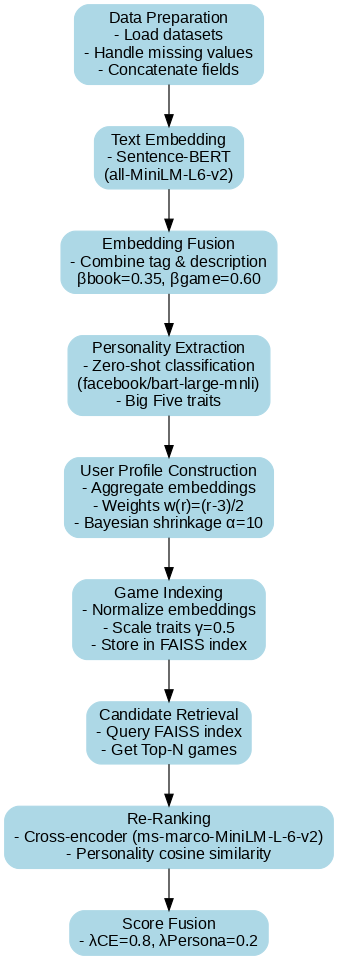

In [ ]:
from graphviz import Digraph
from IPython.display import Image

# Create Digraph object
dot = Digraph(comment="Proposed Cross-Domain Recommendation Model Architecture", format="png")
dot.attr(rankdir="TB", size="8,10")
dot.attr('node', shape='box', style='rounded,filled', color='lightblue', fontname="Helvetica")

# Define nodes
dot.node("DP", "Data Preparation\n- Load datasets\n- Handle missing values\n- Concatenate fields")
dot.node("TE", "Text Embedding\n- Sentence-BERT\n(all-MiniLM-L6-v2)")
dot.node("EF", "Embedding Fusion\n- Combine tag & description\nβbook=0.35, βgame=0.60")
dot.node("PE", "Personality Extraction\n- Zero-shot classification\n(facebook/bart-large-mnli)\n- Big Five traits")
dot.node("UP", "User Profile Construction\n- Aggregate embeddings\n- Weights w(r)=(r-3)/2\n- Bayesian shrinkage α=10")
dot.node("GI", "Game Indexing\n- Normalize embeddings\n- Scale traits γ=0.5\n- Store in FAISS index")
dot.node("CR", "Candidate Retrieval\n- Query FAISS index\n- Get Top-N games")
dot.node("RR", "Re-Ranking\n- Cross-encoder (ms-marco-MiniLM-L-6-v2)\n- Personality cosine similarity")
dot.node("SF", "Score Fusion\n- λCE=0.8, λPersona=0.2")

# Define edges
dot.edge("DP", "TE")
dot.edge("TE", "EF")
dot.edge("EF", "PE")
dot.edge("PE", "UP")
dot.edge("UP", "GI")
dot.edge("GI", "CR")
dot.edge("CR", "RR")
dot.edge("RR", "SF")

# Render & display inline
file_path = "/content/cross_domain_model_architecture"
dot.render(file_path, format="png")
Image(filename=file_path + ".png")


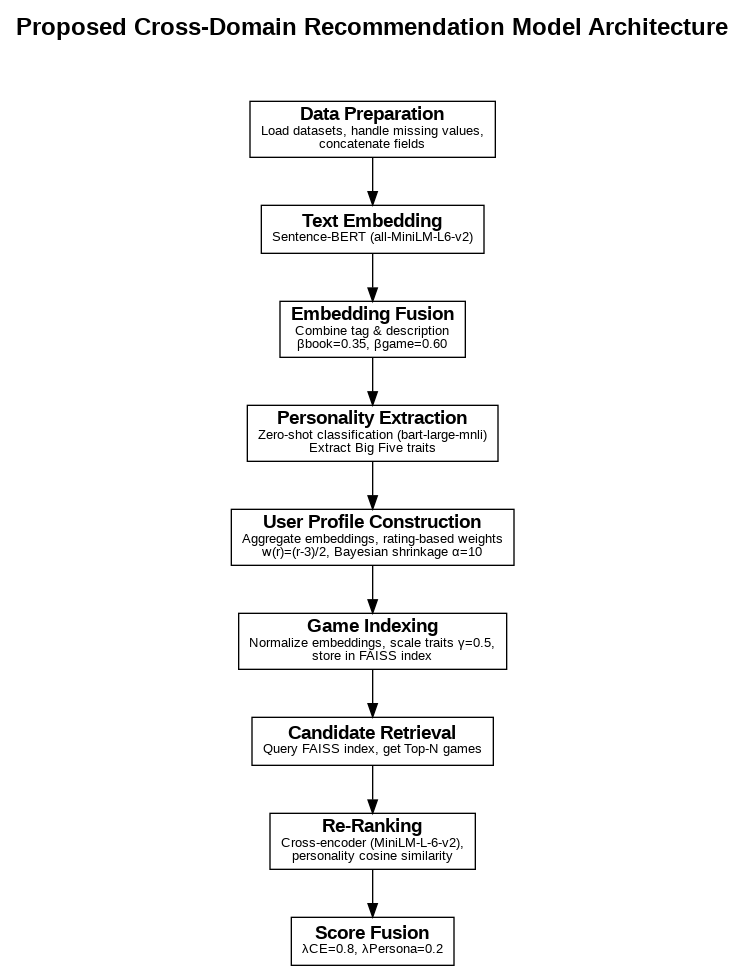

In [ ]:
from graphviz import Digraph
from IPython.display import Image

# Create Digraph object
dot = Digraph(comment="Proposed Cross-Domain Recommendation Model Architecture", format="png")
dot.attr(rankdir="TB", size="8,12")
dot.attr('node', shape='box', style='filled', color='black', fillcolor='white', fontname="Helvetica")

# Title node (not connected, just for figure caption look)
dot.node("TITLE", "Proposed Cross-Domain Recommendation Model Architecture",
         shape="plaintext", fontsize="18", fontname="Helvetica-Bold")

# Define nodes (with bold headers inside each box, escape & as &amp;)
dot.node("DP", """<
<B>Data Preparation</B><BR/>
<FONT POINT-SIZE='10'>Load datasets, handle missing values,<BR/>concatenate fields</FONT>>""")

dot.node("TE", """<
<B>Text Embedding</B><BR/>
<FONT POINT-SIZE='10'>Sentence-BERT (all-MiniLM-L6-v2)</FONT>>""")

dot.node("EF", """<
<B>Embedding Fusion</B><BR/>
<FONT POINT-SIZE='10'>Combine tag &amp; description<BR/>βbook=0.35, βgame=0.60</FONT>>""")

dot.node("PE", """<
<B>Personality Extraction</B><BR/>
<FONT POINT-SIZE='10'>Zero-shot classification (bart-large-mnli)<BR/>Extract Big Five traits</FONT>>""")

dot.node("UP", """<
<B>User Profile Construction</B><BR/>
<FONT POINT-SIZE='10'>Aggregate embeddings, rating-based weights<BR/>w(r)=(r-3)/2, Bayesian shrinkage α=10</FONT>>""")

dot.node("GI", """<
<B>Game Indexing</B><BR/>
<FONT POINT-SIZE='10'>Normalize embeddings, scale traits γ=0.5,<BR/>store in FAISS index</FONT>>""")

dot.node("CR", """<
<B>Candidate Retrieval</B><BR/>
<FONT POINT-SIZE='10'>Query FAISS index, get Top-N games</FONT>>""")

dot.node("RR", """<
<B>Re-Ranking</B><BR/>
<FONT POINT-SIZE='10'>Cross-encoder (MiniLM-L-6-v2),<BR/>personality cosine similarity</FONT>>""")

dot.node("SF", """<
<B>Score Fusion</B><BR/>
<FONT POINT-SIZE='10'>λCE=0.8, λPersona=0.2</FONT>>""")

# Define edges
dot.edge("TITLE", "DP", style="invis")  # title not visually connected
dot.edge("DP", "TE")
dot.edge("TE", "EF")
dot.edge("EF", "PE")
dot.edge("PE", "UP")
dot.edge("UP", "GI")
dot.edge("GI", "CR")
dot.edge("CR", "RR")
dot.edge("RR", "SF")

# Render & display inline
file_path = "/content/cross_domain_model_architecture_clean"
dot.render(file_path, format="png")
Image(filename=file_path + ".png")
